Machine Learning in Transcriptomics: An End-to-End Classification Workflow Using TCGA Gene Expression Data

In this notebook, we will develop machine learning models to distinguish two closely related brain malignancies i-e Astrocytoma and Oligodendroglioma using transcriptomic data obtained from The Cancer Genome Atlas (TCGA). The dataset consists of gene expression measurements for approximately 10,000 genes across 383 patient samples. Throughout this notebook, we will build a complete machine learning pipeline, beginning with data exploration and preprocessing, followed by feature selection, model development, evaluation, and biological interpretation.

In [403]:
# Install required libraries (Run only if the libraries are not already installed)

#!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [1]:
# ==========================================
# Data Manipulation
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Operating System
# ==========================================
import os

# ==========================================
# Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Machine Learning Utilities
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# Feature Selection
# ==========================================
from sklearn.feature_selection import SelectKBest, f_classif

# ==========================================
# Machine Learning Algorithms
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Model Evaluation
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

Understanding the Dataset (Exploratory Data Analysis Before Preprocessing)

Objective

Before building any machine learning model, it is essential to understand the dataset. A machine learning algorithm can only learn meaningful patterns if the input data are properly understood and prepared.

In [3]:
# ==========================================================
# Set Working Directory
# ==========================================================

import os

# Replace this path with your own project directory
working_dir = "//wsl.localhost/Ubuntu/home/aaslam123/SummerSchool2026/Module2/AI_TRANSCRIPT"

# Change the current working directory
os.chdir(working_dir)

# Display the current working directory
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
\\wsl.localhost\Ubuntu\home\aaslam123\SummerSchool2026\Module2\AI_TRANSCRIPT


Loading and Inspecting the Dataset

In [4]:
# ==========================================================
# Load the Datasets
# ==========================================================

# Load the gene expression matrix
expression_data = pd.read_excel("rna_seq.xlsx")

# Load the metadata
metadata = pd.read_excel("meta_data.xlsx")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [5]:
# ==========================================================
# Display the first five rows of the expression matrix
# ==========================================================

print("Expression Matrix")
display(expression_data.head())

Expression Matrix


,Hugo_Symbol,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
0,UBE2Q2P2,8.7141,36.4493,11.8131,8.6116,0.000,5.3382,3.7845,8.3071,2.7732,...,10.3069,51.9703,19.1299,12.5770,10.9796,7.8225,3.3371,5.4526,8.2616,11.5121
1,HMGB1P1,22.7523,21.1767,11.0242,5.0835,30.261,27.8886,8.7230,15.4466,12.7776,...,14.2467,47.4612,21.9905,27.0125,14.2608,16.6975,10.2310,16.1890,19.7074,18.7291
2,RNU12-2P,268.5760,156.6870,185.1380,269.8360,216.341,159.7590,198.1880,208.5410,255.2880,...,119.8610,84.7057,127.7470,106.8290,205.5170,184.4080,125.5470,124.9190,133.7390,120.9240
3,SSX9P,845.8150,390.2690,621.4530,835.7290,812.508,576.9050,551.9470,607.8960,386.1780,...,673.5490,1018.6000,564.3620,603.3720,570.9130,760.7160,875.1410,658.2210,662.6510,524.7240
4,EZHIP,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [6]:
# ==========================================================
# Display the first five rows of the metadata
# ==========================================================

print("Metadata")
display(metadata.head())

Metadata


,SAMPLE_ID,TUMOR_TYPE
0,TCGA-CS-4938-01,Astrocytoma
1,TCGA-CS-4941-01,Astrocytoma
2,TCGA-CS-4942-01,Astrocytoma
3,TCGA-CS-4943-01,Astrocytoma
4,TCGA-CS-4944-01,Astrocytoma


In [7]:
# ==========================================================
# Check the dimensions of both datasets
# ==========================================================

print("Expression Matrix Shape:", expression_data.shape)
print("Metadata Shape:", metadata.shape)

Expression Matrix Shape: (10000, 384)
Metadata Shape: (383, 2)


In [8]:
# ==========================================================
# Display column names
# ==========================================================

print("Expression Matrix Columns")
print(expression_data.columns.tolist())

print("\nMetadata Columns")
print(metadata.columns.tolist())

Expression Matrix Columns
['Hugo_Symbol', 'TCGA-CS-4938-01', 'TCGA-CS-4941-01', 'TCGA-CS-4942-01', 'TCGA-CS-4943-01', 'TCGA-CS-4944-01', 'TCGA-CS-5390-01', 'TCGA-CS-5393-01', 'TCGA-CS-5394-01', 'TCGA-CS-5395-01', 'TCGA-CS-5396-01', 'TCGA-CS-5397-01', 'TCGA-CS-6188-01', 'TCGA-CS-6290-01', 'TCGA-CS-6665-01', 'TCGA-CS-6666-01', 'TCGA-CS-6667-01', 'TCGA-CS-6668-01', 'TCGA-CS-6669-01', 'TCGA-CS-6670-01', 'TCGA-DB-5273-01', 'TCGA-DB-5277-01', 'TCGA-DB-5278-01', 'TCGA-DB-5279-01', 'TCGA-DB-A4XB-01', 'TCGA-DB-A4XD-01', 'TCGA-DB-A4XF-01', 'TCGA-DB-A4XG-01', 'TCGA-DB-A64L-01', 'TCGA-DB-A64P-01', 'TCGA-DB-A64R-01', 'TCGA-DB-A64V-01', 'TCGA-DB-A64X-01', 'TCGA-DB-A75L-01', 'TCGA-DB-A75M-01', 'TCGA-DB-A75O-01', 'TCGA-DB-A75P-01', 'TCGA-DH-5141-01', 'TCGA-DH-5142-01', 'TCGA-DH-5144-01', 'TCGA-DH-A669-01', 'TCGA-DH-A66B-01', 'TCGA-DH-A66D-01', 'TCGA-DH-A66F-01', 'TCGA-DH-A66G-01', 'TCGA-DH-A7UR-01', 'TCGA-DH-A7US-01', 'TCGA-DH-A7UT-01', 'TCGA-DH-A7UU-01', 'TCGA-DH-A7UV-01', 'TCGA-DU-5847-01', 'TCGA-DU

In [9]:
# ==========================================================
# Dataset information
# ==========================================================

print("Expression Matrix Information")
expression_data.info()

print("\nMetadata Information")
metadata.info()

Expression Matrix Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 384 entries, Hugo_Symbol to TCGA-WY-A85C-01
dtypes: float64(383), str(1)
memory usage: 29.3 MB

Metadata Information
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   SAMPLE_ID   383 non-null    str  
 1   TUMOR_TYPE  383 non-null    str  
dtypes: str(2)
memory usage: 6.1 KB


In [10]:
# ==========================================================
# Summary statistics
# ==========================================================

display(expression_data.describe())

,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,TCGA-CS-5396-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
count,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.080721e+03,960.220087,934.330608,830.104015,1.405050e+03,835.250791,849.376208,800.989337,941.038624,937.949363,...,800.020536,815.728097,1.008789e+03,859.368144,932.459621,943.552178,846.584024,857.277005,819.694797,854.557786
std,1.703725e+04,7037.299253,7701.750810,3431.189289,3.253433e+04,3123.515581,3444.057315,2478.135742,5252.658259,4231.079010,...,4136.805048,3520.722546,1.171509e+04,3309.618905,6170.890946,9664.028060,2729.647460,3355.562666,4244.670046,4806.112505
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.936900e+00,7.591400,4.152200,3.586800,3.104275e+00,4.381600,4.841600,2.007400,4.813300,3.477250,...,2.790200,3.853900,6.555400e+00,5.865100,4.206700,5.382400,7.107100,4.750600,3.872600,6.130000
50%,1.327880e+02,186.928500,157.958500,147.712000,1.354180e+02,147.878000,164.616000,122.784000,165.875000,135.593000,...,133.091000,126.201000,1.901070e+02,172.777000,152.644000,174.032000,165.915500,156.495500,155.959500,159.787000
75%,7.678837e+02,810.559000,776.125000,775.284250,7.463032e+02,756.549000,778.697000,726.999000,767.912000,765.703000,...,757.394250,770.496250,7.866777e+02,790.964000,767.578250,803.177000,810.288750,774.479000,771.960000,792.092250
max,1.670180e+06,596225.000000,710357.000000,192399.000000,2.554530e+06,150214.000000,200741.000000,71369.000000,374391.000000,226984.000000,...,294434.000000,208930.000000,1.110890e+06,177916.000000,421501.000000,901579.000000,95528.300000,117899.000000,331327.000000,398922.000000


In [11]:
# download the expression data.describe() to a CSV file inclusing first column as index and without index column
expression_data.describe().to_csv("expression_data_summary.csv", index=True)

In [12]:
# ==========================================================
# Class distribution
# ==========================================================

metadata["TUMOR_TYPE"].value_counts()

TUMOR_TYPE
Astrocytoma          194
Oligodendroglioma    189
Name: count, dtype: int64

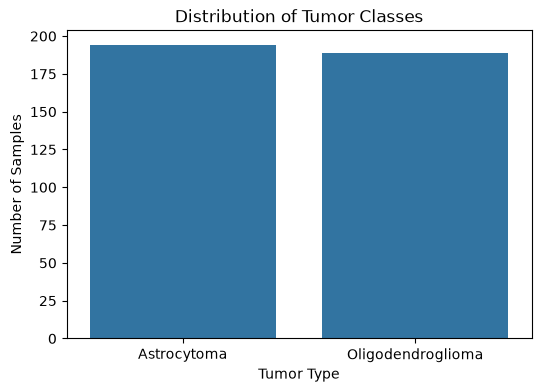

In [13]:
# Visualize the Distribution of Tumor Classes

plt.figure(figsize=(6,4))

sns.countplot(
    data=metadata,
    x="TUMOR_TYPE"
)

plt.title("Distribution of Tumor Classes")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")

plt.show()

In [14]:
# ==========================================================
# Explore the Expression Data
# ==========================================================

print("Minimum Expression Value:",
      expression_data.iloc[:,1:].min().min())

print("Maximum Expression Value:",
      expression_data.iloc[:,1:].max().max())

Minimum Expression Value: 0.0
Maximum Expression Value: 2554530.0


In [15]:
# ==========================================================
# Handling Missing Values
# ==========================================================

print("="*60)
print("Missing Value Assessment")
print("="*60)

before_rows = expression_data.shape[0]

missing_values = expression_data.isnull().sum().sum()

print(f"Total Missing Values: {missing_values}")

# Remove missing values (if any)
expression_data = expression_data.dropna()

after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After  : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Missing Value Assessment
Total Missing Values: 0

Rows Before : 10000
Rows After  : 10000
Rows Removed: 0


In [16]:
# ==========================================================
# Removing Duplicate Rows
# ==========================================================

print("="*60)
print("Duplicate Row Assessment")
print("="*60)

before_rows = expression_data.shape[0]

duplicates = expression_data.duplicated().sum()

print(f"Duplicate Rows Found: {duplicates}")

expression_data = expression_data.drop_duplicates()

after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After  : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Duplicate Row Assessment


Duplicate Rows Found: 0

Rows Before : 10000
Rows After  : 10000
Rows Removed: 0


In [17]:
# ==========================================================
# Remove Lowly Expressed Genes
# ==========================================================

# Define the threshold
zero_threshold = 0.60   # Remove genes with >60% zero expression

# Number of genes before filtering
genes_before = expression_data.shape[0]

# Calculate the fraction of samples with zero expression for each gene
zero_fraction = (expression_data.iloc[:, 1:] == 0).mean(axis=1)

# Keep genes with zero expression in less than 60% of the samples
expression_filtered = expression_data[zero_fraction < zero_threshold]

# Number of genes after filtering
genes_after = expression_filtered.shape[0]

# Display summary
print("="*60)
print("Low Expression Filtering Summary")
print("="*60)

print(f"Threshold Used                : {int(zero_threshold*100)}% zeros")
print(f"Minimum Expression Required   : {int((1-zero_threshold)*100)}% of samples")
print(f"Genes Before Filtering        : {genes_before}")
print(f"Genes After Filtering         : {genes_after}")
print(f"Genes Removed                 : {genes_before - genes_after}")
print(f"Percentage Removed            : {(genes_before - genes_before + (genes_before - genes_after))/genes_before*100:.2f}%")
print(f"Percentage Retained           : {(genes_after/genes_before)*100:.2f}%")

Low Expression Filtering Summary
Threshold Used                : 60% zeros
Minimum Expression Required   : 40% of samples
Genes Before Filtering        : 10000
Genes After Filtering         : 8959
Genes Removed                 : 1041
Percentage Removed            : 10.41%
Percentage Retained           : 89.59%


In [18]:
# ==========================================================
# Inspect the Filtered Dataset
# ==========================================================

print("="*60)
print("Filtered Dataset Dimensions")
print("="*60)

print(f"Number of Genes (Rows)    : {expression_filtered.shape[0]}")
print(f"Number of Samples (Columns): {expression_filtered.shape[1]-1}")

print("\nDataset Shape:", expression_filtered.shape)

Filtered Dataset Dimensions
Number of Genes (Rows)    : 8959
Number of Samples (Columns): 383

Dataset Shape: (8959, 384)


In [19]:
expression_filtered.to_excel(
    os.path.join(working_dir,
                 "01_Low_Expression_Filter.xlsx"),
    index=False
)

Log₂ Transformation

Gene expression values often span several orders of magnitude. Extremely large expression values can dominate the dataset and make it difficult for machine learning algorithms to learn meaningful patterns.

To reduce this effect, we apply a log₂(x + 1) transformation.

Adding 1 ensures that genes with zero expression remain defined after transformation.

This transformation:

- Compresses the dynamic range.
- Reduces right-skewness.
- Makes gene expression values more comparable.
- Improves the suitability of the data for downstream machine learning.

In [20]:
# ==========================================================
# Log2(x + 1) Transformation
# ==========================================================

import numpy as np

# Create a copy of the filtered dataset
expression_log = expression_filtered.copy()

# Expression values before transformation
before_min = expression_filtered.iloc[:, 1:].min().min()
before_max = expression_filtered.iloc[:, 1:].max().max()

# Apply Log2(x + 1) transformation
expression_log.iloc[:, 1:] = np.log2(expression_log.iloc[:, 1:] + 1)

# Expression values after transformation
after_min = expression_log.iloc[:, 1:].min().min()
after_max = expression_log.iloc[:, 1:].max().max()

print("="*60)
print("Log2 Transformation Summary")
print("="*60)

print(f"Minimum Expression Before : {before_min:.2f}")
print(f"Maximum Expression Before : {before_max:.2f}")

print("-"*60)

print(f"Minimum Expression After  : {after_min:.2f}")
print(f"Maximum Expression After  : {after_max:.2f}")

Log2 Transformation Summary
Minimum Expression Before : 0.00
Maximum Expression Before : 2554530.00
------------------------------------------------------------
Minimum Expression After  : 0.00
Maximum Expression After  : 21.28


In [21]:
# ==========================================================
# Save the Log-Transformed Dataset
# ==========================================================

expression_log.to_excel(
    os.path.join(working_dir, "02_Log2_Transformed_Data.xlsx"),
    index=False
)

print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.


Removing Low-Variance Genes

After removing lowly expressed genes and applying a log₂ transformation, some genes may still show very little variation across the samples.

Genes with nearly constant expression provide limited information for distinguishing between Astrocytoma and Oligodendroglioma. Therefore, removing these genes can reduce noise, improve computational efficiency, and simplify the machine learning model.

Unlike the previous filtering step, variance filtering does **not** consider the class labels. It simply measures how much each gene varies across all samples.

In [22]:
# ==========================================================
# Calculate Gene Variance
# ==========================================================

# Calculate variance for each gene
gene_variance = expression_log.iloc[:, 1:].var(axis=1)

print("="*60)
print("Gene Variance Summary")
print("="*60)

print(gene_variance.describe())

Gene Variance Summary
count    8959.000000
mean        1.084351
std         1.303897
min         0.030628
25%         0.243615
50%         0.607613
75%         1.433307
max        23.131853
dtype: float64


In [23]:
# ==========================================================
# Evaluating Different Variance Thresholds
# ==========================================================

thresholds = [0.1, 0.25, 0.5, 1.0]

print("=" * 75)
print(f"{'Threshold':<15}{'Genes Removed':<20}{'Genes Remaining'}")
print("=" * 75)

for threshold in thresholds:

    filtered = expression_log[gene_variance >= threshold]

    removed = expression_log.shape[0] - filtered.shape[0]

    print(f"{threshold:<15}{removed:<20}{filtered.shape[0]}")

Threshold      Genes Removed       Genes Remaining
0.1            326                 8633
0.25           2301                6658
0.5            4033                4926
1.0            5749                3210


In [24]:
# ==========================================================
# Remove Low-Variance Genes
# ==========================================================

# Selected variance threshold
variance_threshold = 0.50

# Calculate variance for each gene
gene_variance = expression_log.iloc[:, 1:].var(axis=1)

# Filter genes
expression_variance_filtered = expression_log[
    gene_variance >= variance_threshold
]

# Summary
genes_before = expression_log.shape[0]
genes_after = expression_variance_filtered.shape[0]

print("="*60)
print("Low Variance Filtering Summary")
print("="*60)

print(f"Variance Threshold Used     : {variance_threshold}")
print(f"Genes Before Filtering      : {genes_before}")
print(f"Genes After Filtering       : {genes_after}")
print(f"Genes Removed               : {genes_before - genes_after}")
print(f"Percentage Removed          : {((genes_before - genes_after)/genes_before)*100:.2f}%")
print(f"Percentage Retained         : {(genes_after/genes_before)*100:.2f}%")

Low Variance Filtering Summary
Variance Threshold Used     : 0.5
Genes Before Filtering      : 8959
Genes After Filtering       : 4926
Genes Removed               : 4033
Percentage Removed          : 45.02%
Percentage Retained         : 54.98%


In [25]:
# ==========================================================
# Final Preprocessed Dataset Dimensions
# ==========================================================

print("="*60)
print("Final Preprocessed Dataset")
print("="*60)

print(f"Number of Genes (Rows)     : {expression_variance_filtered.shape[0]}")
print(f"Number of Samples (Columns): {expression_variance_filtered.shape[1]-1}")
print(f"Dataset Shape              : {expression_variance_filtered.shape}")

Final Preprocessed Dataset
Number of Genes (Rows)     : 4926
Number of Samples (Columns): 383
Dataset Shape              : (4926, 384)


In [26]:
# Save the variance-filtered dataset

expression_variance_filtered.to_excel(
    os.path.join(working_dir, "03_Variance_Filtered_Data.xlsx"),
    index=False
)

print("Variance-filtered dataset saved successfully.")

Variance-filtered dataset saved successfully.


Feature Refinement (Unsupervised)

Before identifying genes that distinguish Astrocytoma from Oligodendroglioma, it is important to refine the feature space by removing redundant information.

In [27]:
# ==========================================================
# Prepare Data for Correlation Analysis
# ==========================================================

# Set Gene ID as index
correlation_data = expression_variance_filtered.set_index(
    expression_variance_filtered.columns[0]
)

print("="*60)
print("Dataset for Correlation Analysis")
print("="*60)

print(f"Genes   : {correlation_data.shape[0]}")
print(f"Samples : {correlation_data.shape[1]}")

correlation_data.head()

Dataset for Correlation Analysis
Genes   : 4926
Samples : 383


,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,TCGA-CS-5396-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
UBE2Q2P2,3.280080,5.226867,3.679548,3.264777,0.000000,2.664073,2.258368,3.218332,1.915789,3.214560,...,3.499132,5.727112,4.331268,3.763093,3.582508,3.141188,2.116731,2.689881,3.211261,3.645252
HMGB1P1,4.569995,4.470973,3.587869,2.604902,4.966292,4.852428,3.281402,4.039717,3.784253,4.388203,...,3.930425,5.598758,4.522966,4.807999,3.931759,4.145474,3.489414,4.103414,4.372075,4.302253
EFCAB8,7.519676,8.348958,7.045945,6.400453,6.352194,7.765018,8.379621,7.939949,7.548737,7.801566,...,9.213430,10.218079,10.177083,8.495739,9.318814,9.701970,8.788836,9.080849,9.255395,9.712114
REXO1L6P,1.631244,2.154032,1.448954,1.204329,2.009383,3.287339,1.935196,1.588517,0.000000,1.911078,...,3.604154,4.592373,3.756479,3.120667,1.138749,3.481144,3.418392,3.068636,3.607342,3.856577
A2BP1,8.304160,9.083235,8.603215,8.665279,6.535924,8.160714,8.398718,9.004350,9.254585,9.049508,...,7.653454,7.721373,7.339013,8.489864,8.146961,7.204786,7.581946,8.497920,8.057938,7.520996


In [28]:
# ==========================================================
# Calculate Gene Correlation Matrix
# ==========================================================

# Transpose the matrix so that genes become columns
correlation_matrix = correlation_data.T.corr(method="pearson")

print("="*60)
print("Correlation Matrix")
print("="*60)

print(f"Shape : {correlation_matrix.shape}")

Correlation Matrix
Shape : (4926, 4926)


In [29]:
# ==========================================================
# Inspecting the Correlation Matrix
# ==========================================================

print("="*70)
print("Correlation Matrix Overview")
print("="*70)

print(f"Number of Genes              : {correlation_matrix.shape[0]}")
print(f"Number of Correlation Values : {correlation_matrix.size:,}")
print(f"Matrix Shape                 : {correlation_matrix.shape}")

Correlation Matrix Overview
Number of Genes              : 4926
Number of Correlation Values : 24,265,476
Matrix Shape                 : (4926, 4926)


In [30]:
# Display the first 10 rows and columns of the correlation matrix
correlation_matrix.iloc[:10, :10]

Hugo_Symbol,UBE2Q2P2,HMGB1P1,EFCAB8,REXO1L6P,A2BP1,A2LD1,A2M,A2ML1,A4GNT,AAA1
Hugo_Symbol,,,,,,,,,,
UBE2Q2P2,1.000000,0.434770,0.336368,0.091031,0.377579,0.438513,0.186488,-0.147520,-0.091253,0.217265
HMGB1P1,0.434770,1.000000,0.190075,0.230961,0.015421,0.185462,0.054656,-0.096910,0.074571,-0.015607
EFCAB8,0.336368,0.190075,1.000000,0.390579,-0.132605,0.573989,-0.115624,0.040885,-0.070669,0.289349
REXO1L6P,0.091031,0.230961,0.390579,1.000000,-0.256454,0.294144,-0.158923,-0.161313,-0.022378,0.124187
A2BP1,0.377579,0.015421,-0.132605,-0.256454,1.000000,0.221490,0.372175,-0.181953,-0.050241,0.178501
A2LD1,0.438513,0.185462,0.573989,0.294144,0.221490,1.000000,0.103066,-0.267499,0.119809,0.444516
A2M,0.186488,0.054656,-0.115624,-0.158923,0.372175,0.103066,1.000000,-0.230425,0.180109,0.152411
A2ML1,-0.147520,-0.096910,0.040885,-0.161313,-0.181953,-0.267499,-0.230425,1.000000,-0.244808,-0.217724
A4GNT,-0.091253,0.074571,-0.070669,-0.022378,-0.050241,0.119809,0.180109,-0.244808,1.000000,-0.040006


In [31]:
# ==========================================================
# Checking Diagonal Values
# ==========================================================

diagonal_values = np.diag(correlation_matrix)

print("="*70)
print("Diagonal Inspection")
print("="*70)

print("Unique values on diagonal:")

print(np.unique(diagonal_values))

Diagonal Inspection
Unique values on diagonal:
[1.]


In [32]:
# ==========================================================
# Extract Upper Triangle
# ==========================================================

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_values = upper_triangle.stack()

print("="*70)
print("Unique Gene Pair Correlations")
print("="*70)

print(f"Total Unique Gene Pairs : {len(correlation_values):,}")

Unique Gene Pair Correlations
Total Unique Gene Pairs : 24,265,476


In [33]:
# ==========================================================
# Correlation Statistics
# ==========================================================

print("="*70)
print("Correlation Summary")
print("="*70)

print(correlation_values.describe())

Correlation Summary
count    1.213028e+07
mean     4.147844e-02
std      2.276056e-01
min     -8.510756e-01
25%     -1.084614e-01
50%      3.054765e-02
75%      1.815535e-01
max      9.937188e-01
dtype: float64


In [34]:
# ==========================================================
# Evaluating Different Correlation Thresholds
# ==========================================================

thresholds = [0.80, 0.85, 0.90, 0.95]

print("="*90)
print(f"{'Threshold':<12}"
      f"{'Correlated Pairs':<22}"
      f"{'Genes Removed':<20}"
      f"{'Genes Remaining'}")
print("="*90)

total_genes = correlation_matrix.shape[0]

for threshold in thresholds:

    # Select upper triangle only
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # Find genes to remove
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    genes_removed = len(to_drop)
    genes_remaining = total_genes - genes_removed

    # Count correlated gene pairs
    correlated_pairs = (
        upper.stack() > threshold
    ).sum()

    print(f"{threshold:<12}"
          f"{correlated_pairs:<22}"
          f"{genes_removed:<20}"
          f"{genes_remaining}")

Threshold   Correlated Pairs      Genes Removed       Genes Remaining
0.8         15030                 924                 4002
0.85        6051                  533                 4393
0.9         1502                  243                 4683
0.95        75                    41                  4885


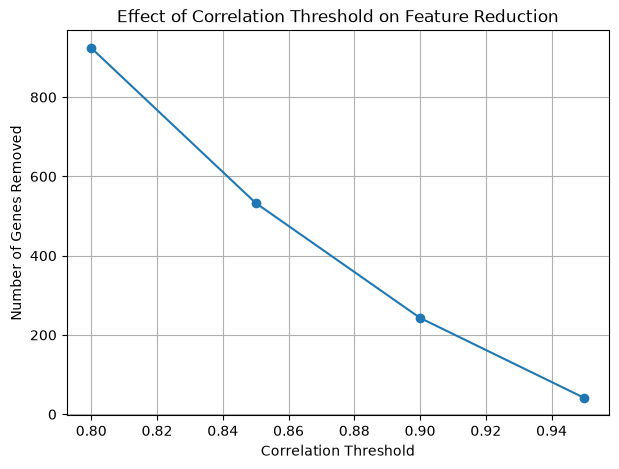

In [35]:
# Plot the number of genes removed against the correlation thresholds
removed_counts = []

for threshold in thresholds:

    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    removed_counts.append(len(to_drop))

plt.figure(figsize=(7,5))

plt.plot(thresholds, removed_counts, marker='o')

plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Genes Removed")
plt.title("Effect of Correlation Threshold on Feature Reduction")

plt.grid(True)

plt.show()

In [36]:
# ==========================================================
# Remove Highly Correlated Genes
# ==========================================================

# Correlation threshold
correlation_threshold = 0.85

# Select upper triangle of the correlation matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Identify genes to remove
genes_to_remove = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

# Remove redundant genes
expression_correlation_filtered = correlation_data.drop(index=genes_to_remove)

print("=" * 60)
print("Correlation Filtering Summary")
print("=" * 60)
print(f"Correlation Method        : Pearson")
print(f"Threshold Used            : {correlation_threshold}")
print(f"Genes Before Filtering    : {correlation_data.shape[0]}")
print(f"Genes Removed             : {len(genes_to_remove)}")
print(f"Genes Remaining           : {expression_correlation_filtered.shape[0]}")
print(f"Percentage Removed        : {len(genes_to_remove)/correlation_data.shape[0]*100:.2f}%")
print(f"Percentage Retained       : {expression_correlation_filtered.shape[0]/correlation_data.shape[0]*100:.2f}%")

Correlation Filtering Summary
Correlation Method        : Pearson
Threshold Used            : 0.85
Genes Before Filtering    : 4926
Genes Removed             : 533
Genes Remaining           : 4393
Percentage Removed        : 10.82%
Percentage Retained       : 89.18%


In [37]:
# ==========================================================
# Save the Refined Dataset
# ==========================================================

# Convert Gene IDs back to a column
expression_correlation_filtered = expression_correlation_filtered.reset_index()

# Save as Excel
expression_correlation_filtered.to_excel(
    "Expression_Data_Correlation_Filtered.xlsx",
    index=False
)

print("\nRefined dataset saved successfully!")
print(f"Final Dataset Shape: {expression_correlation_filtered.shape}")


Refined dataset saved successfully!
Final Dataset Shape: (4393, 384)


Supervised Feature Selection using ANOVA F-test

Does a gene help distinguish Astrocytoma from Oligodendroglioma?

In [38]:
# ==========================================================
# Step 1: Merge Expression Data with Metadata
# ==========================================================

# Load files
expression_data = pd.read_excel("Expression_Data_Correlation_Filtered.xlsx")
metadata = pd.read_excel("meta_data.xlsx")

# Set Gene IDs as index
expression_data = expression_data.set_index(expression_data.columns[0])

# Transpose expression matrix
expression_ml = expression_data.T

# Merge with metadata
merged_data = expression_ml.merge(
    metadata,
    left_index=True,
    right_on="SAMPLE_ID",
    how="inner"
)

print("="*70)
print("Dataset Successfully Merged")
print("="*70)

print("Merged Dataset Shape:", merged_data.shape)

Dataset Successfully Merged
Merged Dataset Shape: (383, 4395)


In [39]:
# ==========================================================
# Dataset Inspection
# ==========================================================

print("="*70)
print("Machine Learning Dataset Summary")
print("="*70)

print(f"Number of Samples : {merged_data.shape[0]}")

print(f"Number of Columns : {merged_data.shape[1]}")

print()

print("Tumor Types")

print(merged_data["TUMOR_TYPE"].value_counts())

print()

print("Missing Labels")

print(merged_data["TUMOR_TYPE"].isna().sum())

Machine Learning Dataset Summary
Number of Samples : 383
Number of Columns : 4395

Tumor Types
TUMOR_TYPE
Astrocytoma          194
Oligodendroglioma    189
Name: count, dtype: int64

Missing Labels
0


In [40]:
# ==========================================================
# Label Encoding
# ==========================================================

label_map = {
    "Astrocytoma": 0,
    "Oligodendroglioma": 1
}

merged_data["Class"] = merged_data["TUMOR_TYPE"].map(label_map)

print("="*70)
print("Encoded Class Distribution")
print("="*70)

print(merged_data["Class"].value_counts())

Encoded Class Distribution
Class
0    194
1    189
Name: count, dtype: int64


In [41]:
# ==========================================================
# Create Feature Matrix and Target Vector
# ==========================================================

X = merged_data.drop(
    columns=[
        "SAMPLE_ID",
        "TUMOR_TYPE",
        "Class"
    ]
)

y = merged_data["Class"]

print("="*70)
print("Machine Learning Dataset")
print("="*70)

print("Feature Matrix Shape :", X.shape)

print("Target Shape         :", y.shape)

Machine Learning Dataset
Feature Matrix Shape : (383, 4393)
Target Shape         : (383,)


In [42]:
from sklearn.model_selection import train_test_split

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% for testing
    stratify=y,           # Preserve class proportions
    random_state=42       # Reproducible results
)

print("=" * 70)
print("Train-Test Split Summary")
print("=" * 70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

Train-Test Split Summary
Training Samples : 306
Testing Samples  : 77
Training Features: 4393
Testing Features : 4393


In [43]:
print("\nTraining Set Class Distribution")
print(y_train.value_counts())

print("\nTesting Set Class Distribution")
print(y_test.value_counts())


Training Set Class Distribution
Class
0    155
1    151
Name: count, dtype: int64

Testing Set Class Distribution
Class
0    39
1    38
Name: count, dtype: int64


In [44]:
# ==========================================================
# Import ANOVA Feature Selection
# ==========================================================

from sklearn.feature_selection import f_classif

In [45]:
# ==========================================================
# Calculate ANOVA F-scores
# ==========================================================

F_scores, p_values = f_classif(X_train, y_train)

print("="*70)
print("ANOVA Completed Successfully")
print("="*70)

print("Total Genes Evaluated :", len(F_scores))

ANOVA Completed Successfully
Total Genes Evaluated : 4393


In [46]:
# ==========================================================
# Create Feature Ranking Table
# ==========================================================

anova_results = pd.DataFrame({
    "Gene": X_train.columns,
    "F_score": F_scores,
    "P_value": p_values
})

anova_results = anova_results.sort_values(
    by="F_score",
    ascending=False
).reset_index(drop=True)

anova_results.head(20)

,Gene,F_score,P_value
0,ASB3,206.407553,4.446954e-36
1,HDGF,184.479221,3.643053e-33
2,CNOT6L,178.323197,2.530523e-32
3,DOLPP1,162.585658,4.033390e-30
4,GRLF1,151.507289,1.591727e-28
5,FNTB,145.021938,1.428080e-27
6,HSCB,141.545171,4.692320e-27
7,FAM198A,139.979370,8.042781e-27
8,KCNJ8,139.858436,8.385243e-27
9,C2orf79,137.331648,2.009324e-26


In [49]:
# ==========================================================
# Number of Significant Genes
# ==========================================================

thresholds = [0.05, 0.01, 0.001, 0.0001]

print("="*70)
print("Significant Genes at Different P-value Thresholds")
print("="*70)

for threshold in thresholds:
    
    count = (anova_results["P_value"] < threshold).sum()
    
    print(f"P-value < {threshold:<8} : {count} genes")

Significant Genes at Different P-value Thresholds
P-value < 0.05     : 2875 genes
P-value < 0.01     : 2434 genes
P-value < 0.001    : 1944 genes
P-value < 0.0001   : 1559 genes


In [50]:
# ==========================================================
# Filter Statistically Significant Genes
# ==========================================================

significant_genes = anova_results[
    anova_results["P_value"] <= 0.05
].copy()

print("="*70)
print("Statistically Significant Genes")
print("="*70)

print(f"Total Significant Genes : {significant_genes.shape[0]}")
print(f"Total Non-significant   : {anova_results.shape[0]-significant_genes.shape[0]}")

Statistically Significant Genes
Total Significant Genes : 2875
Total Non-significant   : 1518


In [51]:
# describe the significant_genes dataframe
significant_genes.describe()

,F_score,P_value
count,2875.000000,2.875000e+03
mean,26.204871,4.832242e-03
std,24.368528,1.045902e-02
min,3.875495,4.446954e-36
25%,8.982343,8.487839e-09
50%,17.197874,4.374291e-05
75%,35.096456,2.950730e-03
max,206.407553,4.990411e-02


In [52]:
# View first 20 significant genes

significant_genes.head(20)

,Gene,F_score,P_value
0,ASB3,206.407553,4.446954e-36
1,HDGF,184.479221,3.643053e-33
2,CNOT6L,178.323197,2.530523e-32
3,DOLPP1,162.585658,4.033390e-30
4,GRLF1,151.507289,1.591727e-28
5,FNTB,145.021938,1.428080e-27
6,HSCB,141.545171,4.692320e-27
7,FAM198A,139.979370,8.042781e-27
8,KCNJ8,139.858436,8.385243e-27
9,C2orf79,137.331648,2.009324e-26


In [53]:
significant_genes.to_excel(
    "ANOVA_Significant_Genes.xlsx",
    index=False
)

In [54]:

#selected_genes = significant_genes.head(top_k)["Gene"]

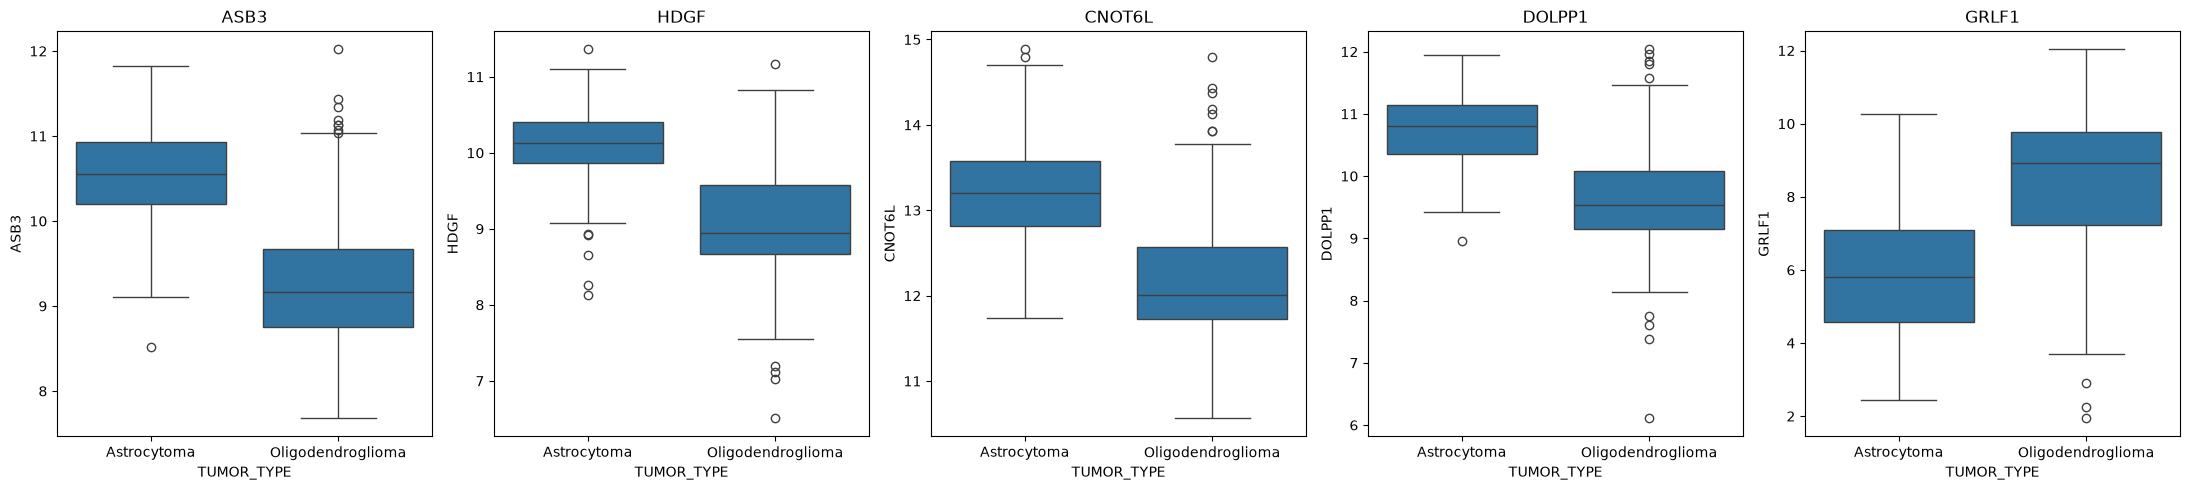

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

top5 = significant_genes.head(5)["Gene"]

fig, axes = plt.subplots(1,5, figsize=(22,5))

for i,gene in enumerate(top5):

    sns.boxplot(
        x=merged_data["TUMOR_TYPE"],
        y=merged_data[gene],
        ax=axes[i]
    )

    axes[i].set_title(gene)

plt.tight_layout()
plt.show()

Final Feature Selection

In [56]:
# ==========================================================
# Define Number of Features to Select
# ==========================================================

# User-defined parameter
# Students can change this value to compare model performance

k = 500

print("="*70)
print("Feature Selection Parameter")
print("="*70)

print(f"Top {k} genes will be selected for machine learning.")

Feature Selection Parameter
Top 500 genes will be selected for machine learning.


In [57]:
# ==========================================================
# Create Final ML Dataset
# ==========================================================

selected_genes = significant_genes.head(k)["Gene"]

X_train_selected = X_train[selected_genes]

X_test_selected = X_test[selected_genes]

print("="*70)
print("Final Machine Learning Dataset")
print("="*70)

print(f"Training Set : {X_train_selected.shape}")

print(f"Testing Set  : {X_test_selected.shape}")

Final Machine Learning Dataset
Training Set : (306, 500)
Testing Set  : (77, 500)


In [58]:
# ==========================================================
# Save Final Datasets
# ==========================================================

X_train_selected.to_excel(
    f"X_train_Top_{k}_Genes.xlsx"
)

X_test_selected.to_excel(
    f"X_test_Top_{k}_Genes.xlsx"
)

print("="*70)
print("Datasets Saved Successfully")
print("="*70)

print(f"Training Dataset : X_train_Top_{k}_Genes.xlsx")

print(f"Testing Dataset  : X_test_Top_{k}_Genes.xlsx")

Datasets Saved Successfully
Training Dataset : X_train_Top_500_Genes.xlsx
Testing Dataset  : X_test_Top_500_Genes.xlsx


Machine Learning Model Building
Model 1: K-Nearest Neighbors (KNN)
Note: KNN requires feature standardization because it relies on distance calculations.

Why StandardScaler? KNN classifies samples by calculating distances between them. If one gene has a much larger numerical range than another, it will dominate the distance calculation. Z-score standardization ensures that every selected gene contributes on a comparable scale, leading to a fairer and more reliable classification model.

In [459]:
# ==========================================================
# Standardize Features
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test_selected)

print("=" * 70)
print("Feature Standardization Completed")
print("=" * 70)

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

Feature Standardization Completed
Training Shape : (306, 500)
Testing Shape  : (77, 500)


In [460]:
# ==========================================================
# Verify Standardization
# ==========================================================

import pandas as pd

scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train_selected.columns
)

print("=" * 70)
print("Summary Statistics After Standardization")
print("=" * 70)

print(scaled_df.iloc[:, :5].describe().loc[["mean", "std"]])

Summary Statistics After Standardization
              ASB3          HDGF        CNOT6L        DOLPP1         GRLF1
mean -1.567374e-16  9.984751e-16  5.993753e-16 -9.984751e-16  8.127123e-17
std   1.001638e+00  1.001638e+00  1.001638e+00  1.001638e+00  1.001638e+00


In [461]:
# ==========================================================
# Convert Scaled Data Back to DataFrame
# ==========================================================

# Convert training data
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    index=X_train_selected.index,
    columns=X_train_selected.columns
)

# Convert testing data
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    index=X_test_selected.index,
    columns=X_test_selected.columns
)

print("="*70)
print("Scaled Training Dataset")
print("="*70)

print(X_train_scaled_df.head())

Scaled Training Dataset
         ASB3      HDGF    CNOT6L    DOLPP1     GRLF1      FNTB      HSCB  \
316 -0.853438 -0.355866 -1.182310 -0.659593  1.340348 -0.945932 -0.919168   
100 -0.522805 -0.451314  0.037124 -0.298418 -0.149657  0.589234 -0.263643   
362  1.069216  0.691649 -0.042058  0.369192  0.367161  0.749857  0.546267   
317 -1.485478 -1.015152 -1.040930 -1.498936  0.910351 -1.424335 -1.343494   
209 -0.118154  1.298354  1.220663  0.604553 -1.408074 -0.499327  0.927290   

      FAM198A     KCNJ8   C2orf79  ...  LINC00930     IL17B     C2CD3  \
316  0.915109  0.882630 -0.971567  ...   0.744661  1.063185  0.571123   
100  0.075395  0.807099 -0.144657  ...   1.104269  2.492627 -0.668153   
362 -0.701722  0.053027  0.918747  ...   0.617891  0.489726  0.193921   
317  0.548081  1.073524 -0.712141  ...  -0.416525 -0.166430  1.288813   
209 -1.098427 -2.021433 -0.371630  ...  -1.150513 -0.534937 -2.755518   

        FOLR2     BUD13       CKM   HMGB1P1    ADAM10      EMR1     CASC3 

In [462]:
# Save scaled datasets

X_train_scaled_df.to_excel(
    f"X_train_Top_{k}_Scaled.xlsx"
)

X_test_scaled_df.to_excel(
    f"X_test_Top_{k}_Scaled.xlsx"
)

In [463]:
# ==========================================================
# Import Required Libraries
# ==========================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [464]:
# ==========================================================
# Define KNN Hyperparameter
# ==========================================================

# Number of nearest neighbors
n_neighbors = 5

print("="*70)
print("KNN Hyperparameter")
print("="*70)

print(f"Number of Neighbors (K) : {n_neighbors}")

KNN Hyperparameter
Number of Neighbors (K) : 5


In [465]:
# ==========================================================
# Initialize KNN Model
# ==========================================================

knn_model = KNeighborsClassifier(
    n_neighbors=n_neighbors
)

print(knn_model)

KNeighborsClassifier()


In [466]:
# ==========================================================
# Train the KNN Model
# ==========================================================

knn_model.fit(
    X_train_scaled_df,
    y_train
)

print("="*70)
print("KNN Model Training Completed Successfully")
print("="*70)

KNN Model Training Completed Successfully


In [467]:
# ==========================================================
# Predict Test Samples
# ==========================================================

y_pred_knn = knn_model.predict(
    X_test_scaled_df
)

print("="*70)
print("Prediction Completed")
print("="*70)

print(f"Total Test Samples : {len(y_test)}")

Prediction Completed
Total Test Samples : 77


In [468]:
# ==========================================================
# Model Performance Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted')
recall = recall_score(y_test, y_pred_knn, average='weighted')
f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("="*70)
print("KNN Performance Metrics")
print("="*70)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

KNN Performance Metrics
Accuracy : 0.8312 (83.12%)
Precision: 0.8421
Recall   : 0.8312
F1 Score : 0.8296


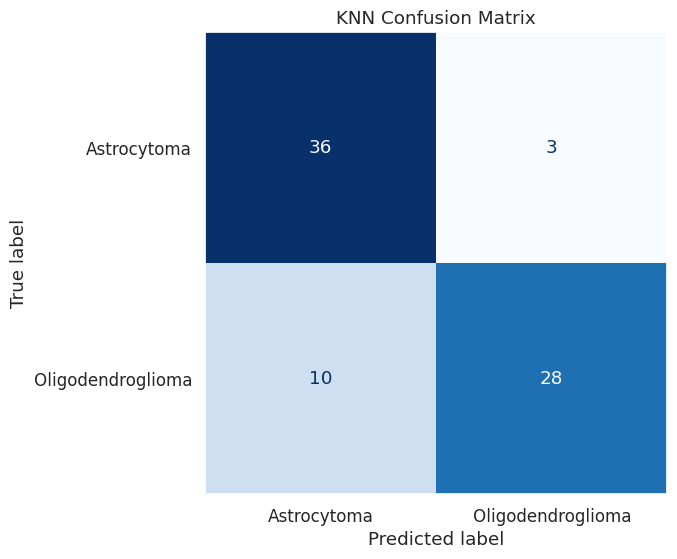

In [469]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_knn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Astrocytoma", "Oligodendroglioma"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("KNN Confusion Matrix")

plt.grid(False)

plt.show()

In [470]:
# ==========================================================
# Actual vs Predicted Labels
# ==========================================================

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_knn
})

comparison.head(10)

,Actual,Predicted
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,1


In [471]:
# ==========================================================
# Save Predictions
# ==========================================================

comparison.to_excel(
    "KNN_Predictions.xlsx",
    index=False
)

print("="*70)
print("Prediction File Saved Successfully")
print("="*70)

Prediction File Saved Successfully


In [472]:
# ==========================================================
# ROC Curve and AUC
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_prob_knn = knn_model.predict_proba(X_test_scaled_df)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob_knn)

print("="*70)
print("ROC Analysis")
print("="*70)

print(f"AUC Score : {auc_score:.4f}")

ROC Analysis
AUC Score : 0.8812


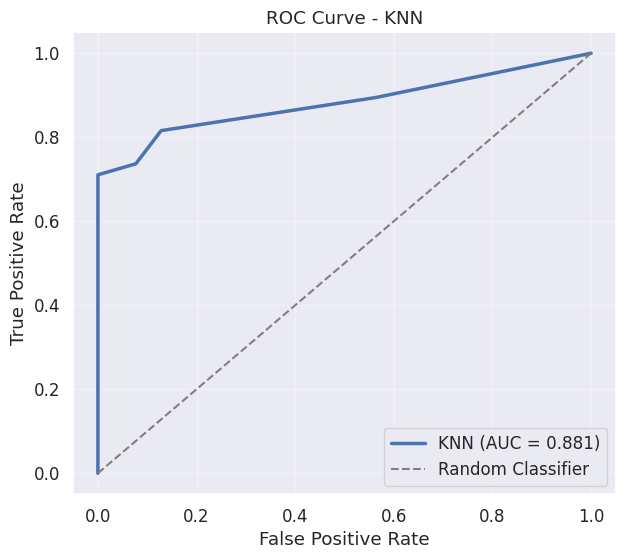

In [473]:
# ==========================================================
# Plot ROC Curve
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"KNN (AUC = {auc_score:.3f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - KNN")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [474]:
# ==========================================================
# Final Performance Summary
# ==========================================================

summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]

})

summary["Value"] = summary["Value"].round(4)

summary

,Metric,Value
0,Accuracy,0.8312
1,Precision,0.8421
2,Recall,0.8312
3,F1-score,0.8296
4,AUC,0.8812


In [475]:
# ==========================================================
# Save KNN Results
# ==========================================================

summary.to_excel("KNN_Performance.xlsx", index=False)

print("="*70)
print("KNN Analysis Completed Successfully")
print("="*70)

print("Files Generated")
print("------------------------------")
print("1. KNN_Performance.xlsx")

KNN Analysis Completed Successfully
Files Generated
------------------------------
1. KNN_Performance.xlsx


Decision Tree Classifier

In [476]:
# ==========================================================
# Import Required Libraries
# ==========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [477]:
# ==========================================================
# Define Decision Tree Parameters
# ==========================================================

max_depth = 5
criterion = "gini"
random_state = 42

print("="*70)
print("Decision Tree Hyperparameters")
print("="*70)

print(f"Criterion     : {criterion}")
print(f"Maximum Depth : {max_depth}")
print(f"Random State  : {random_state}")

Decision Tree Hyperparameters
Criterion     : gini
Maximum Depth : 5
Random State  : 42


In [478]:
# ==========================================================
# Initialize Decision Tree Model
# ==========================================================

dt_model = DecisionTreeClassifier(
    criterion=criterion,
    max_depth=max_depth,
    random_state=random_state
)

print("="*70)
print("Decision Tree Model Initialized")
print("="*70)

print(dt_model)

Decision Tree Model Initialized
DecisionTreeClassifier(max_depth=5, random_state=42)


In [479]:
# ==========================================================
# Train the Decision Tree
# ==========================================================

dt_model.fit(
    X_train_selected,
    y_train
)

print("="*70)
print("Decision Tree Training Completed Successfully")
print("="*70)

Decision Tree Training Completed Successfully


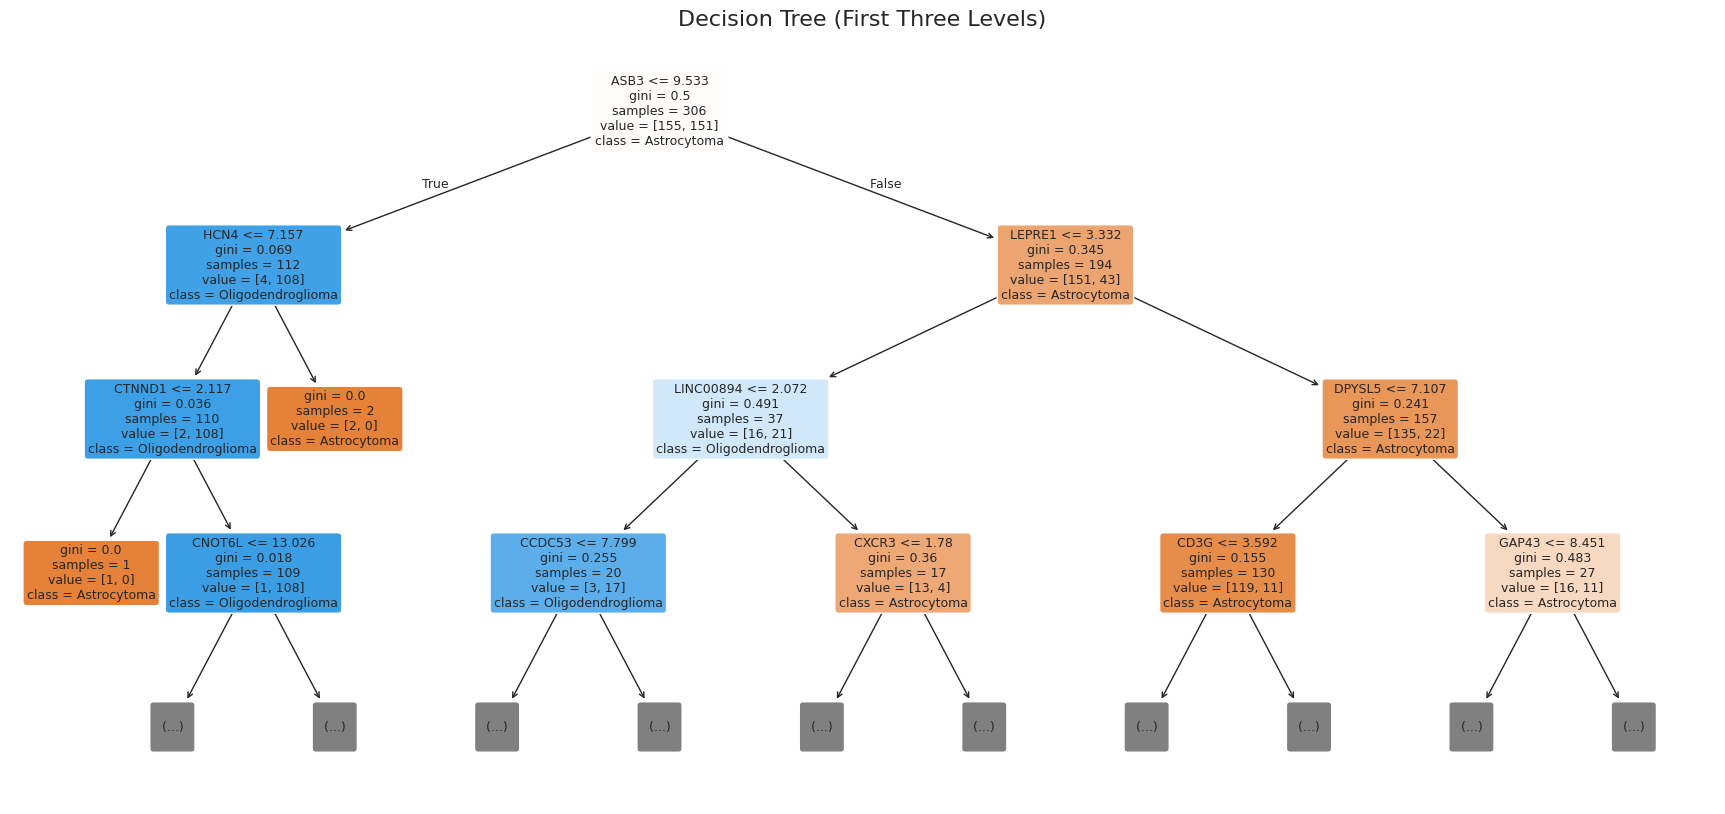

In [480]:
# ==========================================================
# Visualize the Decision Tree
# ==========================================================

plt.figure(figsize=(22,10))

plot_tree(
    dt_model,
    feature_names=X_train_selected.columns,
    class_names=["Astrocytoma", "Oligodendroglioma"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Decision Tree (First Three Levels)", fontsize=16)

plt.show()

In [481]:
# ==========================================================
# Predict Test Samples
# ==========================================================

y_pred_dt = dt_model.predict(
    X_test_selected
)

print("="*70)
print("Prediction Completed Successfully")
print("="*70)

print(f"Total Test Samples : {len(y_test)}")

Prediction Completed Successfully
Total Test Samples : 77


In [482]:
# ==========================================================
# Model Performance
# ==========================================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

print("="*70)
print("Decision Tree Performance Metrics")
print("="*70)

print(f"Accuracy : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Performance Metrics
Accuracy : 0.8312 (83.12%)
Precision: 0.8330
Recall   : 0.8312
F1 Score : 0.8308


In [483]:
# ==========================================================
# Classification Report
# ==========================================================

print("="*70)
print("Classification Report")
print("="*70)

print(classification_report(y_test, y_pred_dt))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        39
           1       0.86      0.79      0.82        38

    accuracy                           0.83        77
   macro avg       0.83      0.83      0.83        77
weighted avg       0.83      0.83      0.83        77



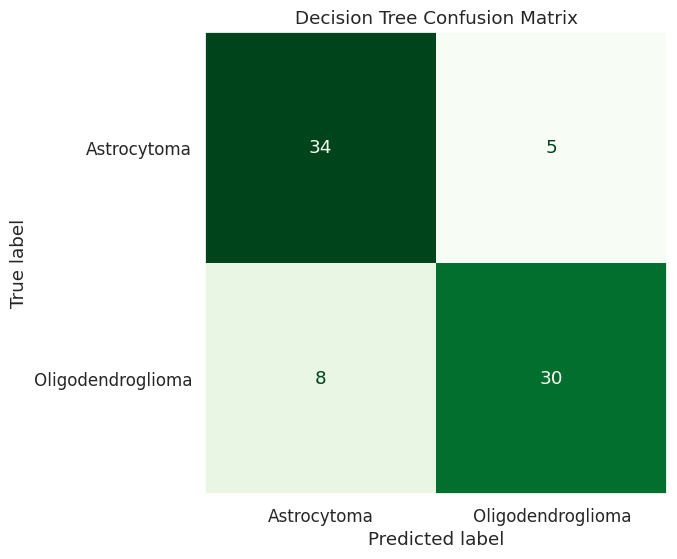

In [484]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Astrocytoma", "Oligodendroglioma"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.grid(False)

plt.show()

In [485]:
# ==========================================================
# Predict Class Probabilities
# ==========================================================

y_prob_dt = dt_model.predict_proba(X_test_selected)[:, 1]

print("="*70)
print("Prediction Probabilities Generated Successfully")
print("="*70)

Prediction Probabilities Generated Successfully


In [486]:
# ==========================================================
# ROC Curve and AUC
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# Calculate AUC
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("="*70)
print("Decision Tree ROC Analysis")
print("="*70)

print(f"AUC Score : {dt_auc:.4f}")

Decision Tree ROC Analysis
AUC Score : 0.8327


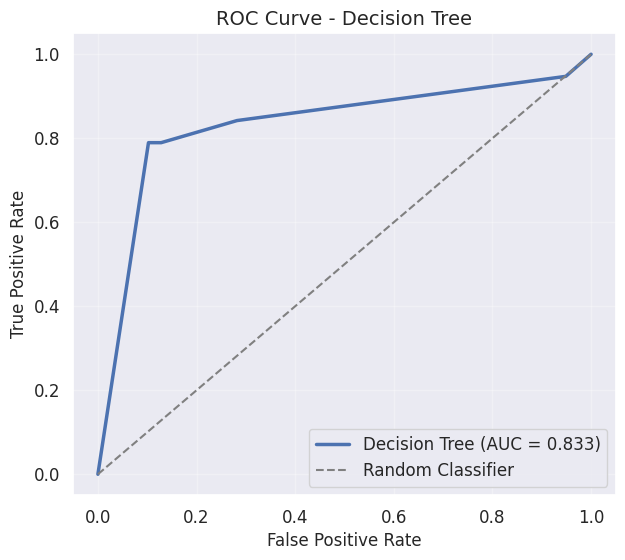

In [487]:
# ==========================================================
# Plot ROC Curve
# ==========================================================

plt.figure(figsize=(7,6))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2.5,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Decision Tree", fontsize=14)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [488]:
# ==========================================================
# Actual vs Predicted Labels
# ==========================================================

dt_predictions = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred_dt

})

print("="*70)
print("Decision Tree Predictions")
print("="*70)

display(dt_predictions.head(20))

Decision Tree Predictions


,Actual,Predicted
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,0


In [489]:
# ==========================================================
# Decision Tree Performance Summary
# ==========================================================

dt_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ]

})

dt_summary["Value"] = dt_summary["Value"].round(4)

dt_summary

,Metric,Value
0,Accuracy,0.8312
1,Precision,0.8330
2,Recall,0.8312
3,F1-score,0.8308
4,AUC,0.8327


In [490]:
# ==========================================================
# Save Decision Tree Results
# ==========================================================

dt_summary.to_excel(
    "DecisionTree_Performance.xlsx",
    index=False
)

dt_predictions.to_excel(
    "DecisionTree_Predictions.xlsx",
    index=False
)

print("="*70)
print("Decision Tree Analysis Completed Successfully")
print("="*70)

print("Files Generated")
print("------------------------------")
print("1. DecisionTree_Performance.xlsx")
print("2. DecisionTree_Predictions.xlsx")

Decision Tree Analysis Completed Successfully
Files Generated
------------------------------
1. DecisionTree_Performance.xlsx
2. DecisionTree_Predictions.xlsx


Random Forest Classifier

In [491]:
# ==========================================================
# Import Required Libraries
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

In [492]:
# ==========================================================
# Random Forest Hyperparameters
# ==========================================================

n_estimators = 200
criterion = "gini"
max_depth = None
random_state = 42
n_jobs = -1

print("="*70)
print("Random Forest Hyperparameters")
print("="*70)

print(f"Number of Trees : {n_estimators}")
print(f"Criterion       : {criterion}")
print(f"Maximum Depth   : {max_depth}")
print(f"Random State    : {random_state}")

Random Forest Hyperparameters
Number of Trees : 200
Criterion       : gini
Maximum Depth   : None
Random State    : 42


In [493]:
# ==========================================================
# Initialize Random Forest
# ==========================================================

rf_model = RandomForestClassifier(

    n_estimators=n_estimators,
    criterion=criterion,
    max_depth=max_depth,
    random_state=random_state,
    n_jobs=n_jobs

)

print(rf_model)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [494]:
# ==========================================================
# Train Random Forest
# ==========================================================

rf_model.fit(
    X_train_selected,
    y_train
)

print("="*70)
print("Random Forest Training Completed Successfully")
print("="*70)

Random Forest Training Completed Successfully


In [495]:
# ==========================================================
# Prediction
# ==========================================================

y_pred_rf = rf_model.predict(X_test_selected)

print("="*70)
print("Prediction Completed Successfully")
print("="*70)

Prediction Completed Successfully


In [496]:
# ==========================================================
# Performance Metrics
# ==========================================================

rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_precision = precision_score(y_test,y_pred_rf,average="weighted")
rf_recall = recall_score(y_test,y_pred_rf,average="weighted")
rf_f1 = f1_score(y_test,y_pred_rf,average="weighted")

print("="*70)
print("Random Forest Performance")
print("="*70)

print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
Accuracy : 0.8571 (85.71%)
Precision: 0.8630
Recall   : 0.8571
F1 Score : 0.8564


In [497]:
print("="*70)
print("Classification Report")
print("="*70)

print(classification_report(
    y_test,
    y_pred_rf
))

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.92      0.87        39
           1       0.91      0.79      0.85        38

    accuracy                           0.86        77
   macro avg       0.86      0.86      0.86        77
weighted avg       0.86      0.86      0.86        77



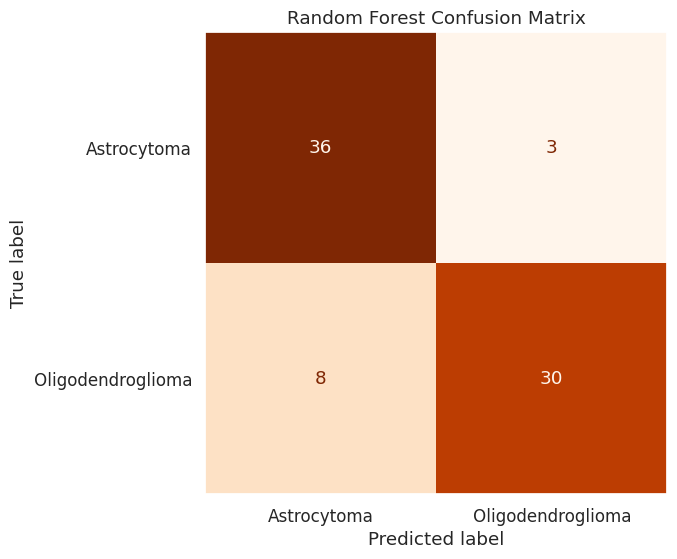

In [498]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_rf,
    display_labels=["Astrocytoma","Oligodendroglioma"]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.grid(False)

plt.show()

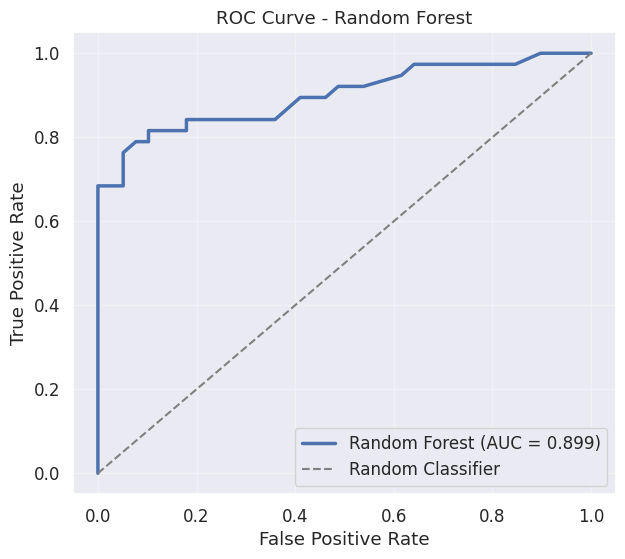

AUC Score : 0.8995


In [499]:
# ==========================================================
# ROC Curve
# ==========================================================

y_prob_rf = rf_model.predict_proba(X_test_selected)[:,1]

fpr_rf,tpr_rf,_ = roc_curve(y_test,y_prob_rf)

rf_auc = roc_auc_score(y_test,y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

print(f"AUC Score : {rf_auc:.4f}")

In [500]:
rf_predictions = pd.DataFrame({

    "Actual":y_test,
    "Predicted":y_pred_rf

})

rf_predictions.head(20)

,Actual,Predicted
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,1


In [501]:
rf_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

rf_summary["Value"] = rf_summary["Value"].round(4)

rf_summary

,Metric,Value
0,Accuracy,0.8571
1,Precision,0.8630
2,Recall,0.8571
3,F1-score,0.8564
4,AUC,0.8995


In [502]:
rf_summary.to_excel(
    "RandomForest_Performance.xlsx",
    index=False
)

rf_predictions.to_excel(
    "RandomForest_Predictions.xlsx",
    index=False
)

In [503]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        recall,
        dt_recall,
        rf_recall
    ],

    "F1-score":[
        f1,
        dt_f1,
        rf_f1
    ],

    "AUC":[
        auc_score,
        dt_auc,
        rf_auc
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,K-Nearest Neighbors,0.8312,0.8421,0.8312,0.8296,0.8812
1,Decision Tree,0.8312,0.8330,0.8312,0.8308,0.8327
2,Random Forest,0.8571,0.8630,0.8571,0.8564,0.8995


In [504]:
comparison.to_excel(
    "Model_Comparison.xlsx",
    index=False
)

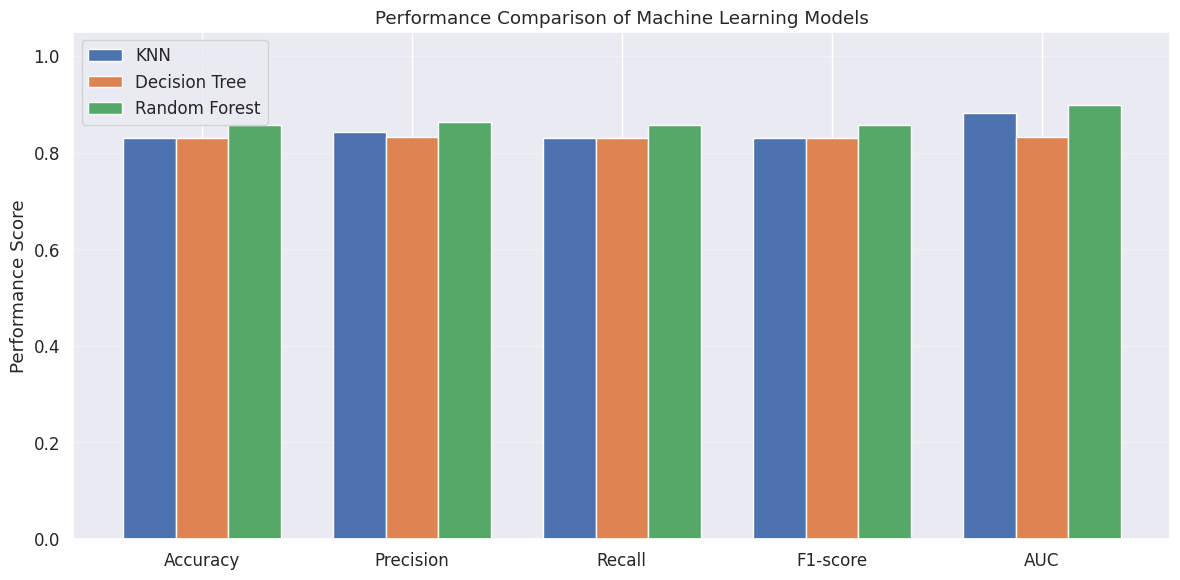

In [505]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy","Precision","Recall","F1-score","AUC"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    x-width,
    comparison.loc[0,metrics],
    width,
    label="KNN"
)

plt.bar(
    x,
    comparison.loc[1,metrics],
    width,
    label="Decision Tree"
)

plt.bar(
    x+width,
    comparison.loc[2,metrics],
    width,
    label="Random Forest"
)

plt.xticks(x,metrics)

plt.ylim(0,1.05)

plt.ylabel("Performance Score")

plt.title("Performance Comparison of Machine Learning Models")

plt.legend()

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.show()

Model Deployment on a New Patient

In [506]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import joblib

In [507]:
# ==========================================================
# Step 2: Load Trained Random Forest Model
# ==========================================================

rf_model = joblib.load(
    "RandomForest_Model.pkl"
)

print("="*70)
print("Random Forest Model Loaded Successfully")
print("="*70)

Random Forest Model Loaded Successfully


In [508]:
# ==========================================================
# Step 3A: Save the Selected Gene List
# (Performed Once During Model Development)
# ==========================================================

selected_genes = X_train_selected.columns

selected_genes.to_series().to_csv(
    "Selected_500_Genes.csv",
    index=False
)

print("="*70)
print("Selected Gene List Saved Successfully")
print("="*70)

print(f"Number of Selected Genes : {len(selected_genes)}")

print("\nFirst 10 Selected Genes\n")
print(selected_genes[:10])

Selected Gene List Saved Successfully
Number of Selected Genes : 500

First 10 Selected Genes

Index(['ASB3', 'HDGF', 'CNOT6L', 'DOLPP1', 'GRLF1', 'FNTB', 'HSCB', 'FAM198A',
       'KCNJ8', 'C2orf79'],
      dtype='object')


In [509]:
# ==========================================================
# Step 3B: Load the Selected Gene List
# (Deployment Phase)
# ==========================================================

selected_genes = pd.read_csv(
    "Selected_500_Genes.csv"
).iloc[:, 0].tolist()

print("="*70)
print("Selected Gene List Loaded Successfully")
print("="*70)

print(f"Number of Required Genes : {len(selected_genes)}")

print("\nFirst 10 Required Genes\n")
print(selected_genes[:10])

Selected Gene List Loaded Successfully
Number of Required Genes : 500

First 10 Required Genes

['ASB3', 'HDGF', 'CNOT6L', 'DOLPP1', 'GRLF1', 'FNTB', 'HSCB', 'FAM198A', 'KCNJ8', 'C2orf79']


In [510]:
# ==========================================================
# Step 4: Load New Patient
# ==========================================================

patient = pd.read_excel(
    "patient_1.xlsx"
)

print("="*70)
print("Patient File Loaded Successfully")
print("="*70)

patient.head()

Patient File Loaded Successfully


,Genes,Patient_001
0,UBE2Q2P2,8.7141
1,HMGB1P1,22.7523
2,RNU12-2P,268.5760
3,SSX9P,845.8150
4,EZHIP,0.0000


In [511]:
# ==========================================================
# Step 5: Set Gene Names as Index
# ==========================================================

patient = patient.set_index("Genes")

print(patient.head())

          Patient_001
Genes                
UBE2Q2P2       8.7141
HMGB1P1       22.7523
RNU12-2P     268.5760
SSX9P        845.8150
EZHIP          0.0000


In [512]:
# ==========================================================
# Step 6: Transpose Matrix
# ==========================================================

patient = patient.T

print("="*70)
print("Patient Matrix Transposed")
print("="*70)

print(patient.shape)

Patient Matrix Transposed
(1, 10000)


In [513]:
# ==========================================================
# Step 7: Log2 Transformation
# ==========================================================

patient = np.log2(patient + 1)

print("="*70)
print("Log Transformation Applied Successfully")
print("="*70)

Log Transformation Applied Successfully


In [514]:
# ==========================================================
# Step 8: Verify Gene Availability
# ==========================================================

missing_genes = list(
    set(selected_genes) -
    set(patient.columns)
)

print("="*70)
print("Gene Verification")
print("="*70)

print(f"Required Genes : {len(selected_genes)}")
print(f"Missing Genes  : {len(missing_genes)}")

Gene Verification
Required Genes : 500
Missing Genes  : 0


In [515]:
# ==========================================================
# Step 9: Select and Arrange Features
# ==========================================================

patient = patient[selected_genes]

print("="*70)
print("Feature Selection Completed")
print("="*70)

print(patient.shape)

Feature Selection Completed
(1, 500)


In [516]:
# ==========================================================
# Step 10: Predict Tumor Type
# ==========================================================

prediction = rf_model.predict(patient)

probability = rf_model.predict_proba(patient)

In [517]:
# ==========================================================
# Step 11: Decode Prediction
# ==========================================================

class_labels = {

    0: "Astrocytoma",
    1: "Oligodendroglioma"

}

predicted_class = class_labels[prediction[0]]

confidence = np.max(probability) * 100

In [518]:
# ==========================================================
# Step 12: Prediction Report
# ==========================================================

print("="*70)
print("Tumor Classification Report")
print("="*70)

print(f"Patient ID              : {patient.index[0]}")
print(f"Uploaded Genes          : {uploaded_genes}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Genes Matched           : {matched_genes}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : Log₂(x + 1)")
print(f"Model Used              : Random Forest")
print(f"Prediction              : {predicted_class}")
print(f"Confidence Score        : {confidence:.2f}%")

print("\nClass Probabilities")
print("-"*70)
print(f"Astrocytoma            : {prob_astro:.2f}%")
print(f"Oligodendroglioma      : {prob_oligo:.2f}%")

if confidence >= 70:
    print("\nInterpretation         : High-confidence prediction")
else:
    print("\nInterpretation         : Low-confidence prediction. Further clinical evaluation is recommended.")

print("="*70)
print("Inference Completed Successfully")
print("="*70)

Tumor Classification Report
Patient ID              : Patient_001
Uploaded Genes          : 10000
Genes Required by Model : 500
Genes Matched           : 500
Missing Genes           : 0
Preprocessing Applied   : Log₂(x + 1)
Model Used              : Random Forest
Prediction              : Astrocytoma
Confidence Score        : 92.00%

Class Probabilities
----------------------------------------------------------------------
Astrocytoma            : 98.11%
Oligodendroglioma      : 1.89%

Interpretation         : High-confidence prediction
Inference Completed Successfully


Decision Tree Model Deployment

In [519]:
# ==========================================================
# Deployment Phase (Decision Tree)
# ==========================================================

import pandas as pd
import numpy as np
import joblib

# ==========================================================
# Step 1: Save the Trained Decision Tree Model
# (Run this only once after training the model)
# ==========================================================

joblib.dump(
    dt_model,
    "DecisionTree_Model.pkl"
)

print("="*70)
print("Decision Tree Model Saved Successfully")
print("="*70)


# ==========================================================
# Step 2: Load the Trained Decision Tree Model
# ==========================================================

dt_model = joblib.load(
    "DecisionTree_Model.pkl"
)

print("="*70)
print("Decision Tree Model Loaded Successfully")
print("="*70)


# ==========================================================
# Step 3: Load Selected Gene List
# ==========================================================

selected_genes = pd.read_csv(
    "Selected_500_Genes.csv"
).iloc[:, 0].tolist()

print("="*70)
print("Selected Gene List Loaded")
print("="*70)
print(f"Number of Required Genes : {len(selected_genes)}")


# ==========================================================
# Step 4: Load New Patient
# ==========================================================

patient = pd.read_excel(
    "patient_1.xlsx"
)

print("="*70)
print("Patient File Loaded Successfully")
print("="*70)

print(patient.head())


# ==========================================================
# Step 5: Set Gene Names as Index
# ==========================================================

patient = patient.set_index("Genes")


# ==========================================================
# Step 6: Transpose Matrix
# ==========================================================

patient = patient.T

uploaded_genes = patient.shape[1]

print("="*70)
print("Patient Matrix Transposed")
print("="*70)

print(f"Matrix Shape : {patient.shape}")


# ==========================================================
# Step 7: Apply Log2(x+1) Transformation
# ==========================================================

patient = np.log2(patient + 1)

print("="*70)
print("Log2 Transformation Applied Successfully")
print("="*70)


# ==========================================================
# Step 8: Verify Required Genes
# ==========================================================

missing_genes = list(
    set(selected_genes) - set(patient.columns)
)

print("="*70)
print("Gene Verification")
print("="*70)

print(f"Required Genes : {len(selected_genes)}")
print(f"Missing Genes  : {len(missing_genes)}")

if len(missing_genes) > 0:
    print("\nMissing Gene List:")
    print(missing_genes)
    raise ValueError("Prediction cannot continue because required genes are missing.")


# ==========================================================
# Step 9: Select and Arrange Required Features
# ==========================================================

patient = patient[selected_genes]

matched_genes = patient.shape[1]

print("="*70)
print("Feature Selection Completed")
print("="*70)

print(f"Final Matrix Shape : {patient.shape}")


# ==========================================================
# Step 10: Predict Tumor Type
# ==========================================================

prediction = dt_model.predict(patient)

probability = dt_model.predict_proba(patient)


# ==========================================================
# Step 11: Decode Prediction
# ==========================================================

class_labels = {
    0: "Astrocytoma",
    1: "Oligodendroglioma"
}

predicted_class = class_labels[prediction[0]]

confidence = np.max(probability) * 100

prob_astro = probability[0][0] * 100
prob_oligo = probability[0][1] * 100

Decision Tree Model Saved Successfully
Decision Tree Model Loaded Successfully
Selected Gene List Loaded
Number of Required Genes : 500
Patient File Loaded Successfully
      Genes  Patient_001
0  UBE2Q2P2       8.7141
1   HMGB1P1      22.7523
2  RNU12-2P     268.5760
3     SSX9P     845.8150
4     EZHIP       0.0000
Patient Matrix Transposed
Matrix Shape : (1, 10000)
Log2 Transformation Applied Successfully
Gene Verification
Required Genes : 500
Missing Genes  : 0
Feature Selection Completed
Final Matrix Shape : (1, 500)


In [520]:
# ==========================================================
# Step 12: Generate Prediction Report
# ==========================================================

print("="*70)
print("Tumor Classification Report")
print("="*70)

print(f"Patient ID              : {patient.index[0]}")
print(f"Uploaded Genes          : {uploaded_genes}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Genes Matched           : {matched_genes}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : Log₂(x + 1)")
print(f"Model Used              : Decision Tree")
print(f"Prediction              : {predicted_class}")
print(f"Confidence Score        : {confidence:.2f}%")

print("\nClass Probabilities")
print("-"*70)
print(f"Astrocytoma            : {prob_astro:.2f}%")
print(f"Oligodendroglioma      : {prob_oligo:.2f}%")

if confidence >= 70:
    print("\nInterpretation         : High-confidence prediction")
else:
    print("\nInterpretation         : Low-confidence prediction. Further clinical evaluation is recommended.")

print("="*70)
print("Inference Completed Successfully")
print("="*70)

Tumor Classification Report
Patient ID              : Patient_001
Uploaded Genes          : 10000
Genes Required by Model : 500
Genes Matched           : 500
Missing Genes           : 0
Preprocessing Applied   : Log₂(x + 1)
Model Used              : Decision Tree
Prediction              : Astrocytoma
Confidence Score        : 98.11%

Class Probabilities
----------------------------------------------------------------------
Astrocytoma            : 98.11%
Oligodendroglioma      : 1.89%

Interpretation         : High-confidence prediction
Inference Completed Successfully
